# Część 2 — Terminale i macierz OD na wybranych parametrach DBSCAN

Po dobraniu parametrów DBSCAN (część 1) puszczam **dalszą część pipeline'u zespołu** — z `trip_extraction_od_matrix.ipynb` — ale na **moich** parametrach `eps=140, min_samples=10`, i porównuję z ich `150/8`.

To nie jest nowa analiza, tylko ten sam łańcuch co u nich (sekcje 7–11 ich notebooka):
1. klastry DBSCAN → terminale typu **cluster**,
2. endpointy-szum (label −1) ratowane przez **POI** (≤250 m) lub **krawędź obszaru** (≤120 m); reszta → **uncertain** (odpada),
3. nazwanie klastrów najbliższym POI z OSM,
4. budowa **macierzy OD** między terminalami (tylko przejazdy z wiarygodnym początkiem i końcem).

**Po co:** sprawdzić, jak mój dobór parametrów przekłada się na końcowy produkt — macierz OD. Kluczowa zależność: **% szumu z DBSCAN = ile endpointów wypada z solidnych klastrów do słabszej ścieżki POI/krawędź/uncertain.**

In [1]:
import numpy as np, pandas as pd, geopandas as gpd
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"font.size":10})

# >>> USTAW ścieżki:
DATA_FILE = "data/2024_11_17_17_00_processed.csv"
OSM_FILE  = "data/external/osm_poi_near_s8.geojson"

EARTH_R = 6_371_000
PARAMS = {  # te same wartości startowe co w głównym pipelinie
    "time_gap_new_trip_s": 5*60, "max_plausible_speed_kmh": 180,
    "min_trip_points": 4, "min_trip_duration_s": 30, "min_trip_distance_m": 200,
    "stop_speed_kmh": 3, "long_stop_s": 3*60,
    "bike_max_reported_speed_kmh": 35, "bike_max_gps_speed_kmh": 45, "bike_median_speed_kmh": 25,
    "car_min_p90_speed_kmh": 45, "car_min_max_speed_kmh": 60,
    "boundary_distance_m": 120, "poi_distance_m": 250,   # progi z ich PARAMS
}

def haversine_m(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2-lat1, lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*EARTH_R*np.arcsin(np.sqrt(a))

In [2]:
def build_trip_stats(csv_path):
    """Odtwarza trip_stats + endpointy (jak część 1 / sekcje 4-8 ich notebooka)."""
    df = pd.read_csv(csv_path, parse_dates=["timestamp","time"]).sort_values(["vehicle_id","timestamp"]).copy()
    g = df.groupby("vehicle_id")
    df["time_diff_s"] = (df["timestamp"]-g["timestamp"].shift(1)).dt.total_seconds()
    df["distance_m"]  = haversine_m(g["lat"].shift(1), g["lon"].shift(1), df["lat"], df["lon"])
    df.loc[df["time_diff_s"].isna(), "distance_m"] = np.nan
    df["gps_speed_kmh"] = (df["distance_m"]/df["time_diff_s"])*3.6
    df["is_stat"] = df["speed"].le(PARAMS["stop_speed_kmh"])
    df["is_jump"] = df["gps_speed_kmh"].gt(PARAMS["max_plausible_speed_kmh"])
    df["sblock"] = g["is_stat"].transform(lambda s: s.ne(s.shift()).cumsum())
    sb = (df[df["is_stat"]].groupby(["vehicle_id","sblock"]).agg(a=("timestamp","min"),b=("timestamp","max")).reset_index())
    sb["dur"]=(sb["b"]-sb["a"]).dt.total_seconds()
    longk=set(map(tuple, sb[sb["dur"]>=PARAMS["long_stop_s"]][["vehicle_id","sblock"]].values))
    df["is_long"]=[k in longk for k in zip(df["vehicle_id"],df["sblock"])]
    df["prev_long"]=df.groupby("vehicle_id")["is_long"].shift(1,fill_value=False)
    df["reason"]="continue"
    df.loc[df["time_diff_s"].isna(),"reason"]="first_point"
    df.loc[df["time_diff_s"].gt(PARAMS["time_gap_new_trip_s"]),"reason"]="time_gap"
    df.loc[df["is_jump"],"reason"]="gps_jump"
    df.loc[df["prev_long"] & ~df["is_long"],"reason"]="after_long_stop"
    df["new_trip"]=df["reason"].ne("continue")
    df["trip_seq"]=df.groupby("vehicle_id")["new_trip"].cumsum()
    df["trip_uid"]=df["vehicle_id"].astype(str)+"_"+df["trip_seq"].astype(str)
    ts=(df.groupby("trip_uid").agg(
        vehicle_id=("vehicle_id","first"), points=("timestamp","size"),
        start_time=("timestamp","min"), end_time=("timestamp","max"),
        start_lat=("lat","first"), start_lon=("lon","first"), end_lat=("lat","last"), end_lon=("lon","last"),
        origin_region=("region","first"), destination_region=("region","last"),
        gps_speed_max=("gps_speed_kmh","max"), distance_m=("distance_m","sum"), implausible=("is_jump","sum"),
        rep_med=("speed","median"), rep_p90=("speed",lambda s:s.quantile(0.9)), rep_max=("speed","max")).reset_index())
    ts["duration_s"]=(ts["end_time"]-ts["start_time"]).dt.total_seconds()
    ts["valid_basic"]=~(ts["points"].lt(PARAMS["min_trip_points"]) | ts["duration_s"].lt(PARAMS["min_trip_duration_s"])
        | ts["distance_m"].lt(PARAMS["min_trip_distance_m"]) | ts["implausible"].gt(0))
    bike=(ts["rep_max"].le(PARAMS["bike_max_reported_speed_kmh"]) & ts["gps_speed_max"].le(PARAMS["bike_max_gps_speed_kmh"]) & ts["rep_med"].le(PARAMS["bike_median_speed_kmh"]))
    car=(ts["rep_p90"].ge(PARAMS["car_min_p90_speed_kmh"]) | ts["rep_max"].ge(PARAMS["car_min_max_speed_kmh"]))
    ts["mode_class"]=np.select([bike,car],["bike_or_slow","car_like"],default="uncertain")
    ts["usable"]=ts["valid_basic"] & ts["mode_class"].eq("car_like")
    return ts

trip_stats = build_trip_stats(DATA_FILE)

# endpointy (origin+destination uzytecznych przejazdow) - z regionem, jak u nich
u=trip_stats[trip_stats["usable"]]
o=u[["trip_uid","start_lat","start_lon","origin_region"]].rename(columns={"start_lat":"lat","start_lon":"lon","origin_region":"region"}); o["endpoint_type"]="origin"
d=u[["trip_uid","end_lat","end_lon","destination_region"]].rename(columns={"end_lat":"lat","end_lon":"lon","destination_region":"region"}); d["endpoint_type"]="destination"
endpoints_base=pd.concat([o,d],ignore_index=True)
print("przejazdy:",len(trip_stats),"| uzyteczne:",int(trip_stats.usable.sum()),"| endpointy:",len(endpoints_base))

# POI z OSM (jak ich cell 48)
osm=gpd.read_file(OSM_FILE); osm=osm[osm.geometry.type=="Point"].copy()
poi=pd.DataFrame({"poi_name":osm["poi_name"].fillna("OSM object").values,
                  "poi_type":osm["poi_type"].fillna("osm").values,
                  "lat":osm.geometry.y.values,"lon":osm.geometry.x.values})
poi_gdf=gpd.GeoDataFrame(poi,geometry=gpd.points_from_xy(poi.lon,poi.lat),crs="EPSG:4326").to_crs(2180)
poi["name_priority"]=0  # uproszczone; pelne priorytety w ich cell 50
print("POI:",len(poi))

przejazdy: 2722 | uzyteczne: 2204 | endpointy: 4408


POI: 23121


## Funkcja: pełny pipeline terminali + macierz OD dla zadanych `(eps, min_samples)`

Wierna kopia ich logiki: DBSCAN → krawędzie → POI → `terminal_id` (precedencja **cluster > poi > boundary**) → macierz OD na przejazdach z wiarygodnym początkiem i końcem.

In [3]:
def build_terminals_and_od(eps_m, ms):
    ep = endpoints_base.copy().reset_index(drop=True)
    X = np.radians(ep[["lat","lon"]].to_numpy())
    ep["endpoint_cluster"] = DBSCAN(eps=eps_m/EARTH_R, min_samples=ms, metric="haversine").fit_predict(X)
    n_clusters = ep.loc[ep.endpoint_cluster>=0,"endpoint_cluster"].nunique()

    gp = gpd.GeoDataFrame(ep, geometry=gpd.points_from_xy(ep.lon, ep.lat), crs="EPSG:4326").to_crs(2180)
    minx,miny,maxx,maxy = gp.total_bounds
    bd = pd.DataFrame({"west":gp.geometry.x-minx, "east":maxx-gp.geometry.x,
                       "south":gp.geometry.y-miny, "north":maxy-gp.geometry.y})
    ep["boundary_side"] = bd.idxmin(axis=1).values
    ep["near_boundary"] = bd.min(axis=1).values <= PARAMS["boundary_distance_m"]

    near = gpd.sjoin_nearest(gp[["geometry"]].copy(), poi_gdf, how="left", distance_col="dist")
    near = near[~near.index.duplicated(keep="first")]
    ep["nearest_poi"] = near["poi_name"].values
    ep["near_poi"] = near["dist"].values <= PARAMS["poi_distance_m"]

    def rel(r):
        if r.endpoint_cluster>=0: return "cluster"
        if r.near_boundary: return "boundary"
        if r.near_poi: return "poi"
        return "uncertain"
    ep["reliability"] = ep.apply(rel, axis=1)

    # terminal_id: boundary -> poi -> cluster (cluster nadpisuje)
    ep["terminal_id"] = "uncertain"
    mb=ep.near_boundary; ep.loc[mb,"terminal_id"]="boundary_"+ep.loc[mb,"boundary_side"].astype(str)
    mp=ep.near_poi;      ep.loc[mp,"terminal_id"]="poi_"+ep.loc[mp,"nearest_poi"].astype(str)
    mc=ep.endpoint_cluster>=0; ep.loc[mc,"terminal_id"]="cluster_"+ep.loc[mc,"endpoint_cluster"].astype(str)

    # nazwa klastra wg najblizszego POI (jak ich cell 50, na centroidach)
    cs = ep[ep.endpoint_cluster>=0].groupby("endpoint_cluster").agg(lat=("lat","mean"),lon=("lon","mean")).reset_index()
    cs_gdf = gpd.GeoDataFrame(cs, geometry=gpd.points_from_xy(cs.lon,cs.lat), crs="EPSG:4326").to_crs(2180)
    cs_near = gpd.sjoin_nearest(cs_gdf, poi_gdf, how="left", distance_col="dist")
    cs_near = cs_near[~cs_near.index.duplicated(keep="first")]
    label_map = {}
    for cl,nm,dd in zip(cs.endpoint_cluster, cs_near["poi_name"].values, cs_near["dist"].values):
        nm = "" if (pd.isna(nm) or str(nm).lower()=="osm object") else f"_{nm}"
        label_map[cl] = f"c{cl}{nm}"[:28]

    # macierz OD
    O=ep[ep.endpoint_type=="origin"][["trip_uid","terminal_id","reliability"]].rename(columns={"terminal_id":"o_term","reliability":"o_rel"})
    D=ep[ep.endpoint_type=="destination"][["trip_uid","terminal_id","reliability"]].rename(columns={"terminal_id":"d_term","reliability":"d_rel"})
    od=trip_stats.merge(O,on="trip_uid",how="left").merge(D,on="trip_uid",how="left")
    rl={"cluster","boundary","poi"}
    od["reliable_od"]=(od.valid_basic & od.mode_class.eq("car_like") & od.o_rel.isin(rl) & od.d_rel.isin(rl) & od.o_term.ne(od.d_term))
    rt=od[od.reliable_od]
    mat=pd.crosstab(rt.o_term,rt.d_term)
    terms=pd.unique(pd.concat([rt.o_term,rt.d_term]))
    info=dict(n_clusters=n_clusters, terminals=len(terms), reliable_trips=int(od.reliable_od.sum()))
    return ep, od, mat, info, label_map

## Porównanie: parametry zespołu (150/8) vs moje (140/10)

In [4]:
results = {}
rows = []
for eps, ms in [(150,8),(140,10)]:
    ep, od, mat, info, lab = build_terminals_and_od(eps, ms)
    results[(eps,ms)] = (ep, od, mat, lab)
    rc = ep.reliability.value_counts().to_dict()
    rows.append({"konfiguracja":f"{eps}/{ms}", "klastry_DBSCAN":info["n_clusters"],
                 "terminale_OD":info["terminals"], "wiarygodne_przejazdy":info["reliable_trips"],
                 "endpointy_cluster":rc.get("cluster",0), "endpointy_poi":rc.get("poi",0),
                 "endpointy_boundary":rc.get("boundary",0), "endpointy_uncertain":rc.get("uncertain",0)})
pd.DataFrame(rows)

,konfiguracja,klastry_DBSCAN,terminale_OD,wiarygodne_przejazdy,endpointy_cluster,endpointy_poi,endpointy_boundary,endpointy_uncertain
0,150/8,48,78,2052,4279,117,6,6
1,140/10,47,102,2046,4128,232,7,41


## Co mówi to porównanie — uczciwie

To jest najważniejszy wniosek całej części 2 i nie jest jednoznaczny:

- **Liczba wiarygodnych przejazdów w macierzy OD jest praktycznie taka sama** (≈2050 w obu wariantach). Czyli wybór parametrów w zakresie 140–150 / 8–10 **prawie nie zmienia** wielkości końcowego produktu.
- **150/8 mocniej kotwiczy endpointy w klastrach** (więcej `cluster`, mniej `poi`/`uncertain`). Niższy szum DBSCAN (2.9%) oznacza, że więcej punktów ma solidny terminal-klaster, a mniej trafia do słabszej ścieżki POI.
- **140/10 daje więcej terminali, ale głównie przez fragmentację POI**: dodatkowy szum (6.4%) to więcej endpointów `poi_…`, z których każdy bywa osobnym terminalem o byle jakiej nazwie (często „OSM object"), plus więcej `uncertain`, które odpadają. To raczej rozdrobnienie niż lepsza granularność.

**Wniosek dla projektu:** na poziomie macierzy OD przewaga 140/10 z części 1 (lepszy silhouette, ciaśniejsze klastry) **się nie przekłada** na wyraźnie lepszy wynik — bo o kształcie macierzy decyduje przede wszystkim to, jak pipeline obsługuje szum. Jeśli celem jest macierz **maksymalnie oparta na klastrach** (a nie na łatce POI), to niżej-szumowe **150/8 jest tu nawet odrobinę czystsze**. Jeśli celem jest lepsza separacja na etapie samego klastrowania — 140/10. Różnica w liczbie przejazdów jest pomijalna.

To jest dobre, dojrzałe zdanie do prowadzącego: *„dobór parametrów DBSCAN w rozsądnym zakresie daje niemal identyczną macierz OD; o jakości terminali decyduje obsługa szumu, dlatego warto raportować % szumu i udział endpointów typu cluster/poi/uncertain przy każdym przebiegu."*

## Macierz OD na 140/10 — największe przepływy

In [5]:
ep, od, mat, lab = results[(140,10)]
rt = od[od.reliable_od].copy()

def nice(t):
    if t.startswith("cluster_"):
        return lab.get(int(t.split("_")[1]), t)
    return t.replace("poi_","poi:")[:28]

top = (rt.groupby(["o_term","d_term"]).size().sort_values(ascending=False).head(15).reset_index(name="przejazdy"))
top["origin"] = top.o_term.map(nice); top["destination"] = top.d_term.map(nice)
top[["origin","destination","przejazdy"]]

,origin,destination,przejazdy
0,c9,c1_Centrum Olimpijskie 01,107
1,c1_Centrum Olimpijskie 01,c9,94
2,c5_Wiejska 02,c6_Warszawa Zachód,61
3,c6_Warszawa Zachód,c5_Wiejska 02,56
4,c5_Wiejska 02,c0,45
5,c0,c5_Wiejska 02,42
6,c6_Warszawa Zachód,c9,39
7,c12,c24_Konwaliowa 02,33
8,c0,c9,32
9,c9,c0,28


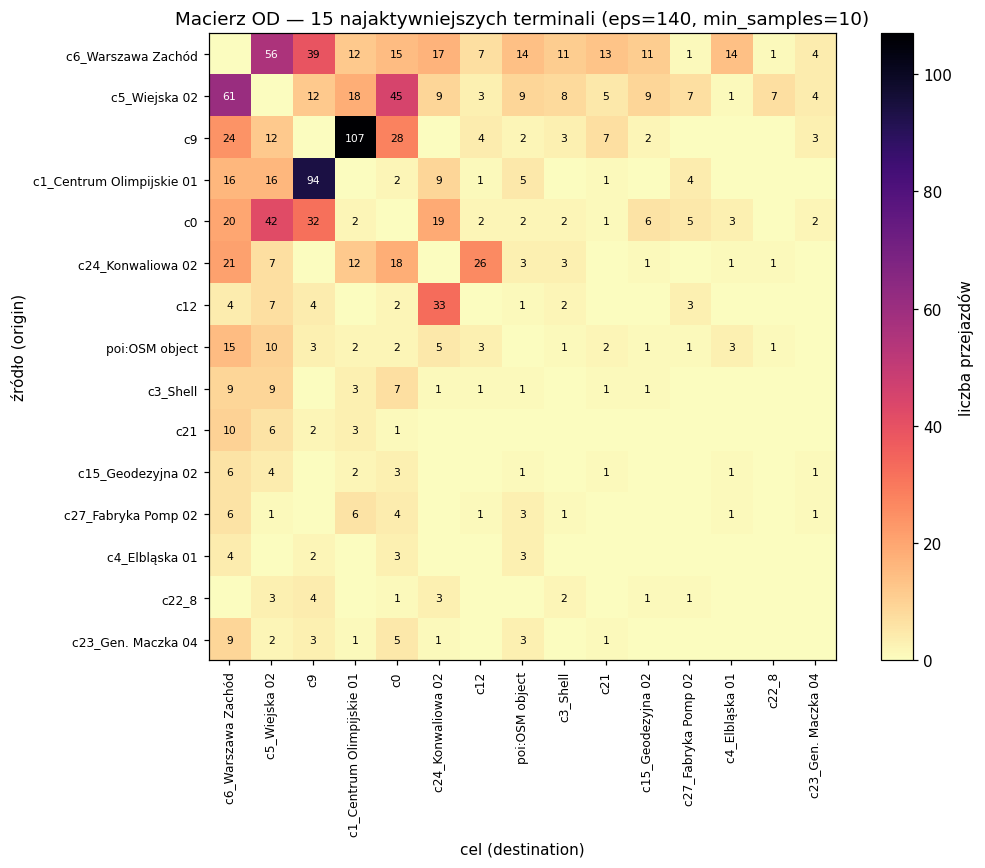

In [6]:
# Heatmapa OD dla najaktywniejszych terminali (140/10)
flow = rt.groupby("o_term").size().add(rt.groupby("d_term").size(), fill_value=0).sort_values(ascending=False)
topN = flow.head(15).index.tolist()
sub = mat.reindex(index=topN, columns=topN, fill_value=0)
labels = [nice(t) for t in topN]
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(sub.values, cmap="magma_r")
ax.set_xticks(range(len(topN))); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(topN))); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("cel (destination)"); ax.set_ylabel("źródło (origin)")
ax.set_title("Macierz OD — 15 najaktywniejszych terminali (eps=140, min_samples=10)")
for i in range(len(topN)):
    for j in range(len(topN)):
        v=sub.values[i,j]
        if v>0: ax.text(j,i,int(v),ha="center",va="center",fontsize=7,
                        color="white" if v>sub.values.max()*0.5 else "black")
fig.colorbar(im,ax=ax,fraction=0.046,label="liczba przejazdów")
fig.tight_layout(); plt.show()

## Mapa przepływów OD (140/10)

Linie łączą centroidy terminali; grubość ~ liczba przejazdów. Pokazuję 25 najsilniejszych relacji.

In [7]:
import folium
cent = ep[ep.endpoint_cluster>=0].groupby("terminal_id").agg(lat=("lat","mean"),lon=("lon","mean"),n=("trip_uid","size"))
# centroidy takze dla poi/boundary terminali
other = ep[ep.reliability.isin(["poi","boundary"])].groupby("terminal_id").agg(lat=("lat","mean"),lon=("lon","mean"),n=("trip_uid","size"))
cent = pd.concat([cent, other])
cent = cent[~cent.index.duplicated(keep="first")]

pairs = rt.groupby(["o_term","d_term"]).size().sort_values(ascending=False).head(25)
m = folium.Map(location=[ep.lat.mean(), ep.lon.mean()], zoom_start=11, tiles="CartoDB positron")
mx = pairs.max()
for (o_t,d_t),w in pairs.items():
    if o_t in cent.index and d_t in cent.index:
        a=cent.loc[o_t]; b=cent.loc[d_t]
        folium.PolyLine([(a.lat,a.lon),(b.lat,b.lon)], weight=1+6*w/mx, opacity=0.55, color="#0050b3",
                        tooltip=f"{nice(o_t)} → {nice(d_t)}: {int(w)} przejazdów").add_to(m)
for t,r in cent.iterrows():
    if t in set(pairs.index.get_level_values(0))|set(pairs.index.get_level_values(1)):
        folium.CircleMarker([r.lat,r.lon], radius=3+np.log1p(r.n), color="#c0392b", fill=True,
                            fill_opacity=0.8, tooltip=f"{nice(t)} ({int(r.n)} endpointów)").add_to(m)
m.save("od_flow_map_140_10.html")
m

## Uwaga techniczna: ID klastrów się przenumerowują

`cluster_0`, `cluster_1`, … to **arbitralne numery** nadawane przez DBSCAN i **zmieniają się przy każdej zmianie `eps`/`min_samples`**. Pipeline używa `terminal_id = "cluster_<id>"`, więc „cluster_5" przy 140/10 to inne miejsce niż przy 150/8. **Porównując dwa przebiegi, dopasowuj terminale po położeniu (centroidzie), nie po numerze.** Dlatego w tabelach powyżej etykietuję klastry najbliższym POI, a nie samym numerem.

## Podsumowanie i co dalej

- Puściłam pełny pipeline terminali + macierz OD (wiernie wg ich notebooka) dla **140/10** i **150/8**.
- **Macierz OD jest niemal identyczna** (≈2050 wiarygodnych przejazdów). Główna różnica: 140/10 przesuwa ~150 endpointów z klastrów do ścieżki POI i ~35 do `uncertain`, co daje więcej, ale bardziej rozdrobnionych terminali.
- Praktyczny wniosek: w zakresie 140–150 / 8–10 wybór parametrów ma **mały wpływ na macierz OD**; o jakości decyduje obsługa szumu. Dla macierzy opartej na klastrach niżej-szumowe 150/8 jest minimalnie czystsze.

**Co dalej (otwarte):**
1. **Jakość nazw POI** — policzyć, ile terminali `poi_…` to „OSM object"/bezużyteczne nazwy; te wymagają ręcznego oznaczenia.
2. **Stabilność w czasie** — powtórzyć na innej godzinie/dniu i dopasować terminale po centroidach; dopiero to potwierdza, że terminale są realne.
3. **Symetria macierzy** — sprawdzić, czy przepływy A→B i B→A są zbliżone (powinny, dla ruchu dwukierunkowego na S8).

**Zastrzeżenie:** to jedna godzina danych i ślady wybranych telefonów (nie pełne natężenie ruchu), więc macierz OD jest poglądowa, nie pomiarowa.